ARTI308 - Machine Learning

# Lab 4: Exploratory Data Analysis (EDA) - Food Delivery Orders

In this lab, I used a Food Delivery Orders dataset and applied the EDA steps before using the data for machine learning.

The main things I checked were the dataset size, data types, missing values, duplicate rows, distributions, relationships between variables, correlation, and the monthly sales trend.

### Dataset Topic

Each row represents one food delivery order. The dataset has information about the order date, city, customer type, meal type, cuisine, restaurant, number of items, order amount, delivery fee, total amount, delivery time, payment method, and customer rating.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

### Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("Food_Delivery_Orders.csv")

df.head()

,Order ID,Order Date,City,Customer Type,Meal Type,Cuisine,Restaurant,Items Ordered,Order Amount,Delivery Fee,Total Amount,Delivery Time (min),Payment Method,Customer Rating
0,FD-00001,2025-08-17 18:06:00,Khobar,Normal,Dinner,Healthy,Urban Bites,2,61.35,12.37,75.75,39,E-Wallet,9.5
1,FD-00002,2025-09-08 10:25:00,Jeddah,Member,Breakfast,Saudi,Rice & Spice,6,88.88,13.53,106.43,34,E-Wallet,8.4
2,FD-00003,2025-09-03 12:30:00,Riyadh,Member,Lunch,Healthy,Family Grill,7,314.02,5.73,315.07,38,E-Wallet,9.3
3,FD-00004,2025-07-20 14:26:00,Khobar,Member,Lunch,Italian,Family Grill,1,24.14,3.83,26.74,40,E-Wallet,8.0
4,FD-00005,2025-02-13 19:03:00,Dammam,Member,Dinner,Italian,Wok Express,3,160.83,12.23,179.41,36,E-Wallet,8.0


Each row in the dataset is one food delivery order. There are categorical columns such as City, Cuisine, Restaurant, and Payment Method, and numerical columns such as Items Ordered, Total Amount, Delivery Time, and Customer Rating.

### Check Missing Values

In [3]:
# Check missing values
df.isna()

,Order ID,Order Date,City,Customer Type,Meal Type,Cuisine,Restaurant,Items Ordered,Order Amount,Delivery Fee,Total Amount,Delivery Time (min),Payment Method,Customer Rating
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
df.isna().sum()

Order ID               0
Order Date             0
City                   0
Customer Type          0
Meal Type              0
Cuisine                0
Restaurant             0
Items Ordered          0
Order Amount           0
Delivery Fee           0
Total Amount           0
Delivery Time (min)    0
Payment Method         0
Customer Rating        0
dtype: int64

I checked the dataset for missing values using `isna().sum()`. The result shows that there are no missing values in the columns.

### Check Duplicate Rows

In [5]:
# Check duplicate rows
df.duplicated()[df.duplicated() == True]

Series([], dtype: bool)

I checked for duplicate rows. No duplicate rows were found, so there was no need to remove duplicates.

### No. of Rows and Columns

In [6]:
# Number of rows and columns
print("Shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns): (1500, 14)
Number of rows: 1500
Number of columns: 14


### Data Type of Columns

In [7]:
# Data types
df.dtypes

Order ID                object
Order Date              object
City                    object
Customer Type           object
Meal Type               object
Cuisine                 object
Restaurant              object
Items Ordered            int64
Order Amount           float64
Delivery Fee           float64
Total Amount           float64
Delivery Time (min)      int64
Payment Method          object
Customer Rating        float64
dtype: object

In [8]:
# Change Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df.dtypes

Order ID                       object
Order Date             datetime64[ns]
City                           object
Customer Type                  object
Meal Type                      object
Cuisine                        object
Restaurant                     object
Items Ordered                   int64
Order Amount                  float64
Delivery Fee                  float64
Total Amount                  float64
Delivery Time (min)             int64
Payment Method                 object
Customer Rating               float64
dtype: object

The Order Date column was changed to datetime so it can be used for the time analysis. The other numerical columns were already in numerical format.

### Descriptive Summary Statistics

In [9]:
# Descriptive statistics
df.describe(include='all')

,Order ID,Order Date,City,Customer Type,Meal Type,Cuisine,Restaurant,Items Ordered,Order Amount,Delivery Fee,Total Amount,Delivery Time (min),Payment Method,Customer Rating
count,1500,1500,1500,1500,1500,1500,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500.000000
unique,1500,NaN,5,2,4,5,10,NaN,NaN,NaN,NaN,NaN,3,NaN
top,FD-00001,NaN,Riyadh,Member,Dinner,Saudi,Rice & Spice,NaN,NaN,NaN,NaN,NaN,E-Wallet,NaN
freq,1,NaN,433,868,559,335,166,NaN,NaN,NaN,NaN,NaN,648,NaN
mean,NaN,2025-06-29 15:10:32,NaN,NaN,NaN,NaN,NaN,4.538667,144.691213,9.451987,154.056687,35.358000,NaN,8.504867
min,NaN,2025-01-01 08:10:00,NaN,NaN,NaN,NaN,NaN,1.000000,11.450000,3.540000,10.930000,15.000000,NaN,5.500000
25%,NaN,2025-03-25 06:26:45,NaN,NaN,NaN,NaN,NaN,3.000000,72.267500,6.590000,81.180000,29.000000,NaN,8.000000
50%,NaN,2025-07-02 07:51:00,NaN,NaN,NaN,NaN,NaN,5.000000,127.740000,9.485000,137.935000,36.000000,NaN,8.500000
75%,NaN,2025-10-03 00:13:00,NaN,NaN,NaN,NaN,NaN,7.000000,199.745000,12.245000,209.762500,42.000000,NaN,9.025000
max,NaN,2025-12-31 22:00:00,NaN,NaN,NaN,NaN,NaN,8.000000,468.390000,15.530000,474.990000,70.000000,NaN,10.000000


The `describe()` output gives summary statistics such as count, mean, standard deviation, minimum, and maximum. It gives a quick idea about the numerical values in the dataset.

## Univariate Analysis

### Distribution of Items Ordered

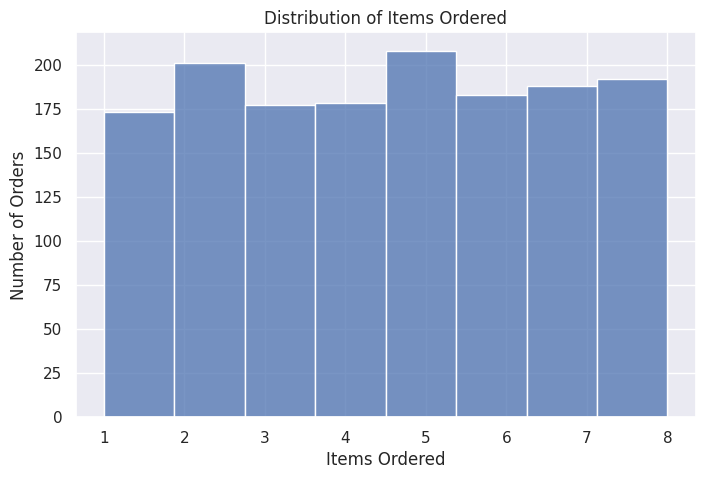

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Items Ordered'], bins=8, color='C0')
plt.title("Distribution of Items Ordered")
plt.xlabel("Items Ordered")
plt.ylabel("Number of Orders")
plt.show()

Most orders have a relatively small number of items. Orders with a higher number of items are less common.

### Distribution of Total Order Amount

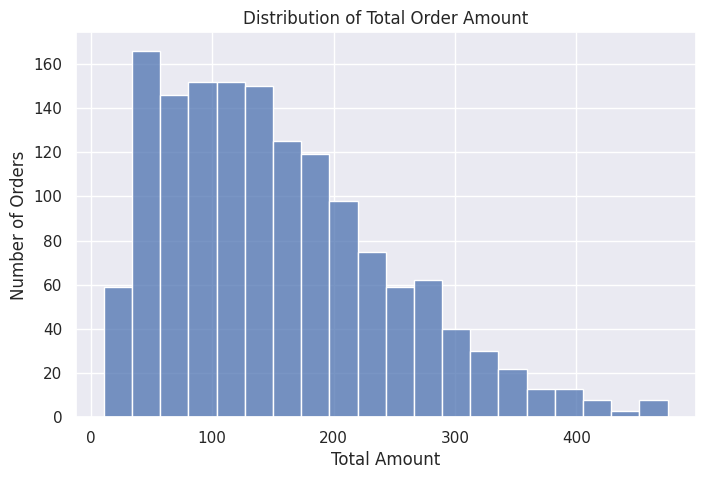

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Amount'], bins=20, color='C0')
plt.title("Distribution of Total Order Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Orders")
plt.show()

The total amount has a range of values. Most orders are in the lower and middle part of the distribution, with some higher-value orders.

## Bivariate Analysis

### Total Sales by City

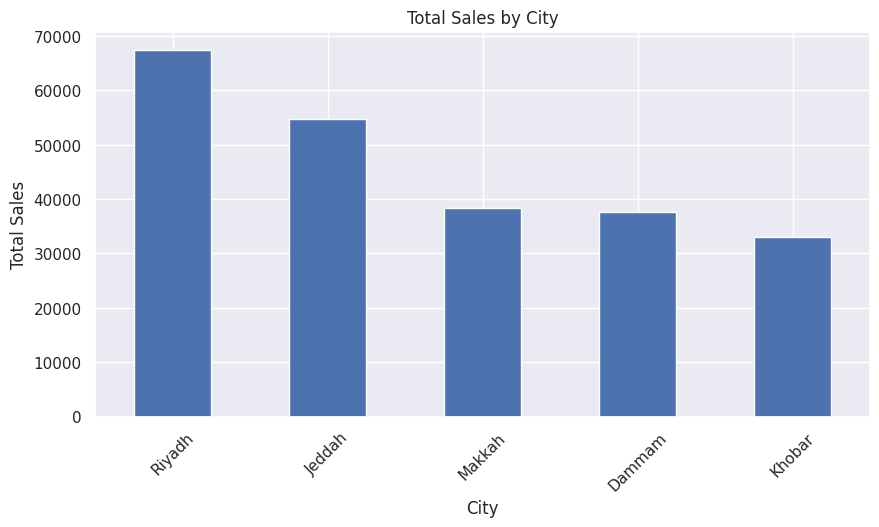

In [12]:
city_sales = df.groupby('City')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
city_sales.plot(kind='bar')
plt.title("Total Sales by City")
plt.ylabel("Total Sales")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()

Riyadh has the highest total sales in this dataset, with total sales of about 67,459.33.

### Total Sales by Cuisine

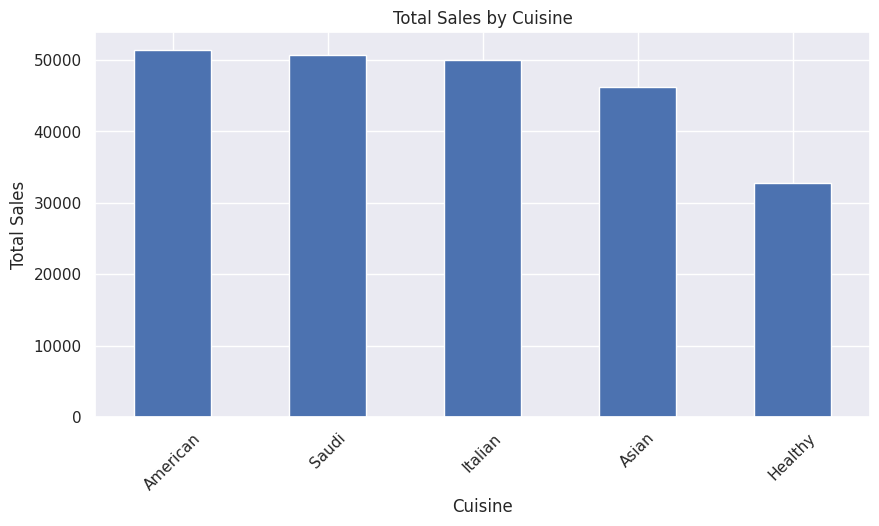

In [13]:
cuisine_sales = df.groupby('Cuisine')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
cuisine_sales.plot(kind='bar')
plt.title("Total Sales by Cuisine")
plt.ylabel("Total Sales")
plt.xlabel("Cuisine")
plt.xticks(rotation=45)
plt.show()

American cuisine has the highest total sales in this dataset, about 51,337.36.

### Total Sales by Restaurant (Top 10)

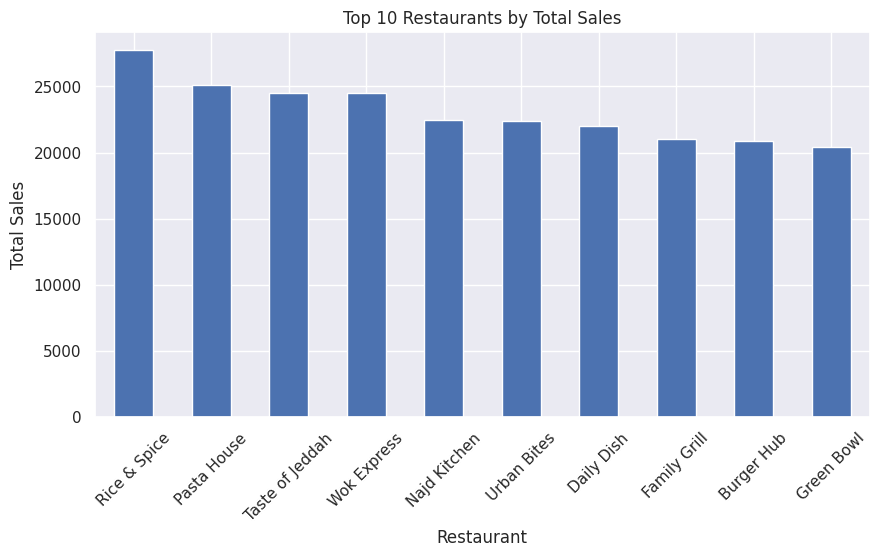

In [14]:
restaurant_sales = df.groupby('Restaurant')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
restaurant_sales.head(10).plot(kind='bar')
plt.title("Top 10 Restaurants by Total Sales")
plt.ylabel("Total Sales")
plt.xlabel("Restaurant")
plt.xticks(rotation=45)
plt.show()

Rice & Spice has the highest total sales among the restaurants shown, with about 27,720.28.

### Items Ordered vs Total Sales Relationship

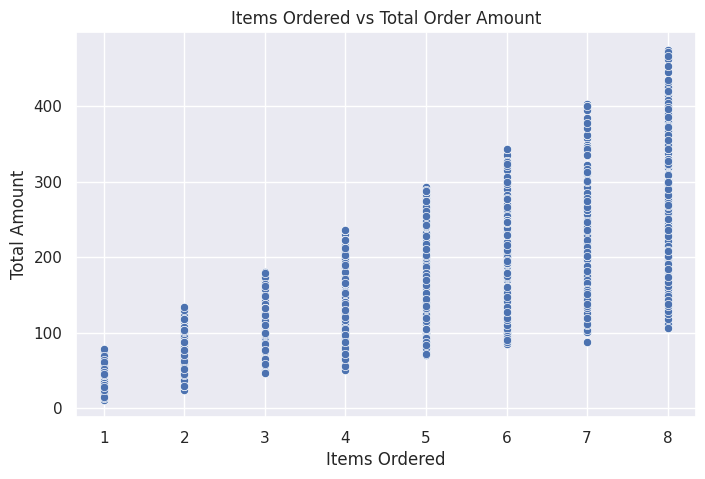

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Items Ordered', y='Total Amount', data=df, color='C0')
plt.title("Items Ordered vs Total Order Amount")
plt.xlabel("Items Ordered")
plt.ylabel("Total Amount")
plt.show()

The scatter plot shows a positive relationship between Items Ordered and Total Amount. The correlation is about 0.78, so orders with more items usually have a higher total amount.

### Correlation Matrix

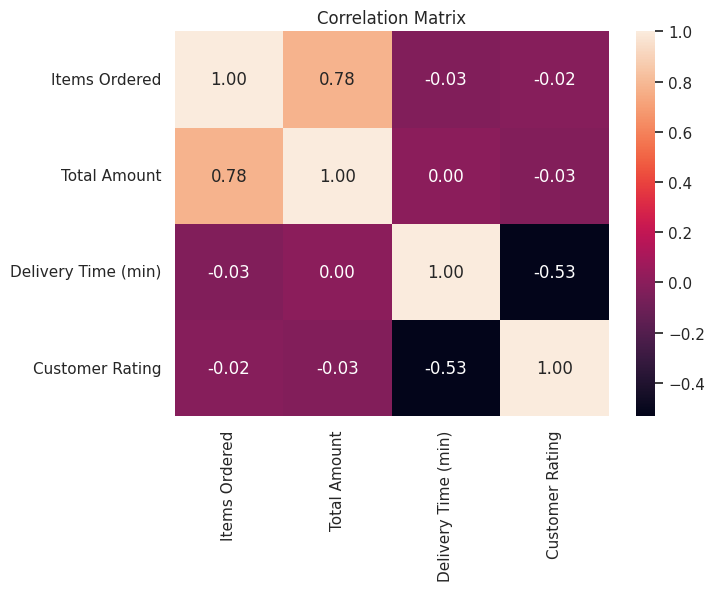

In [16]:
plt.figure(figsize=(7,5))
sns.heatmap(
    df[['Items Ordered', 'Total Amount', 'Delivery Time (min)', 'Customer Rating']].corr(),
    annot=True,
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix was used to compare the numerical columns. The strongest relationship in the selected variables is between Items Ordered and Total Amount.

### Total Sales by Payment Method

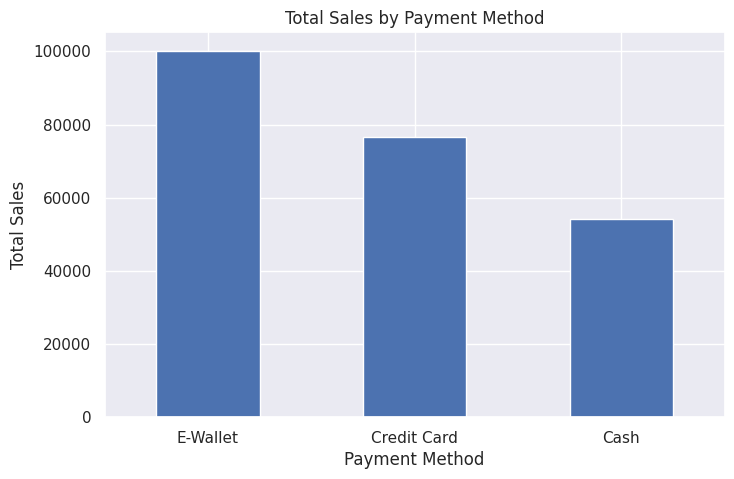

In [17]:
payment_sales = df.groupby('Payment Method')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_sales.plot(kind='bar')
plt.title("Total Sales by Payment Method")
plt.ylabel("Total Sales")
plt.xlabel("Payment Method")
plt.xticks(rotation=0)
plt.show()

E-Wallet has the highest total sales among the payment methods in this dataset.

## Time-Based Analysis
### Monthly Total Sales Trend

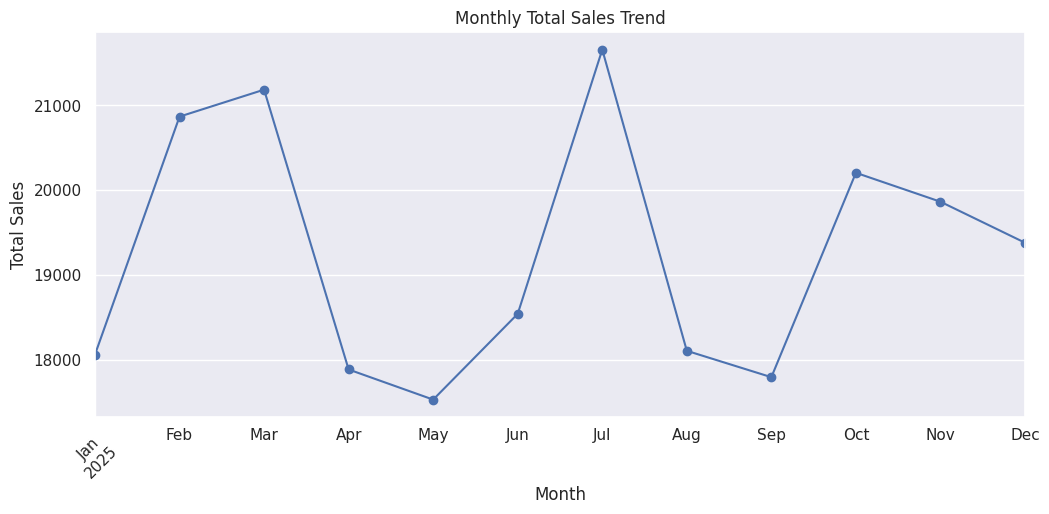

In [18]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

The monthly sales values change from month to month. July 2025 has the highest monthly total in this dataset, with about 21,657.42.

## Additional Outlier Check

In [19]:
# IQR outlier check for Total Amount
q1 = df['Total Amount'].quantile(0.25)
q3 = df['Total Amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['Total Amount'] < lower_bound) | (df['Total Amount'] > upper_bound)]

print("Number of possible outliers:", len(outliers))
outliers.head()

Number of possible outliers: 21


,Order ID,Order Date,City,Customer Type,Meal Type,Cuisine,Restaurant,Items Ordered,Order Amount,Delivery Fee,Total Amount,Delivery Time (min),Payment Method,Customer Rating,Month
50,FD-00051,2025-09-01 19:12:00,Riyadh,Member,Dinner,American,Rice & Spice,8,468.39,10.57,474.99,55,E-Wallet,7.1,2025-09
75,FD-00076,2025-09-25 18:05:00,Dammam,Normal,Dinner,Italian,Taste of Jeddah,8,404.27,11.37,419.13,39,E-Wallet,7.7,2025-09
98,FD-00099,2025-08-06 12:37:00,Jeddah,Normal,Lunch,Asian,Daily Dish,8,410.70,5.44,414.58,32,E-Wallet,8.0,2025-08
107,FD-00108,2025-04-08 20:42:00,Khobar,Member,Dinner,Italian,Wok Express,8,439.92,6.79,445.57,47,E-Wallet,6.6,2025-04
247,FD-00248,2025-08-29 12:45:00,Riyadh,Normal,Lunch,American,Wok Express,7,405.31,5.96,402.72,35,Cash,7.9,2025-08


I used the IQR method to check for unusual Total Amount values. I did not remove possible outliers because an unusually large order can still be a real order.

# Assignment / Conclusion

In this lab, I performed EDA on the Food Delivery Orders dataset. First, I checked the shape, columns, data types, missing values, duplicate rows, and descriptive statistics.

Then I used graphs to look at the number of items ordered and the total order amount. I also compared total sales by city, cuisine, restaurant, and payment method.

The scatter plot showed a positive relationship between Items Ordered and Total Amount, with a correlation of about 0.78. I also checked the monthly sales trend and used the IQR method to check for possible outliers.

Overall, the dataset has both categorical and numerical information, so it can be useful for further analysis or a future machine learning task.